In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/customer_feedback_satisfaction.csv")
population_mean = df["SatisfactionScore"].mean()
print("Population size:", len(df))
print("True population mean:", population_mean)

Population size: 38444
True population mean: 85.27640906253252


In [ ]:
sample = df.sample(n=300, replace=False, random_state=3214)
sample_mean = sample["SatisfactionScore"].mean()
print(sample_mean)

84.58366666666667


In [ ]:
x_bar = sample_mean
s = sample["SatisfactionScore"].std()
n = len(sample)
z = 1.96

margin_error = z * (s / np.sqrt(n))

lower = x_bar - margin_error
upper = x_bar + margin_error

print("Sample mean:", x_bar)
print("Confidence Interval:", lower, upper)

Sample mean: 84.58366666666667
Confidence Interval: 82.65196127480523 86.51537205852811


In [ ]:
means = []

for i in range(10000):
  sample = df.sample(n=50, replace=False)
  means.append(sample["SatisfactionScore"].mean())



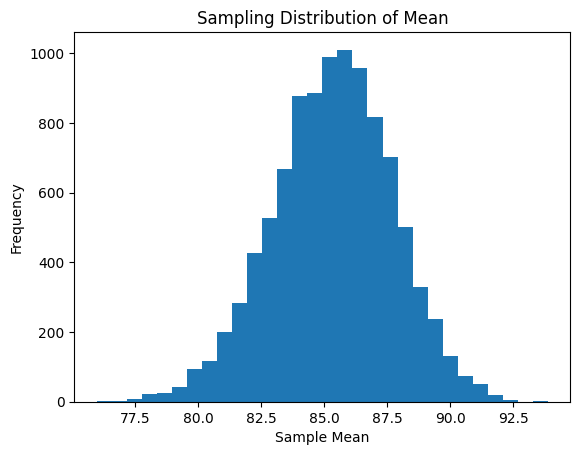

In [ ]:
plt.hist(means, bins = 30)
plt.title("Sampling Distribution of Mean")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()

In [ ]:
count = 0

for i in range(10000):
  sample = df.sample(n=50, replace = False)

  mean = sample["SatisfactionScore"].mean()
  std = sample["SatisfactionScore"].std()

  se = std / np.sqrt(len(sample))

  margin_error = 1.96 * se

  lower = mean - margin_error
  upper = mean + margin_error

  if lower <= population_mean <= upper:
    count += 1

print("Coverage rate:", count/10000)

Coverage rate: 0.9372


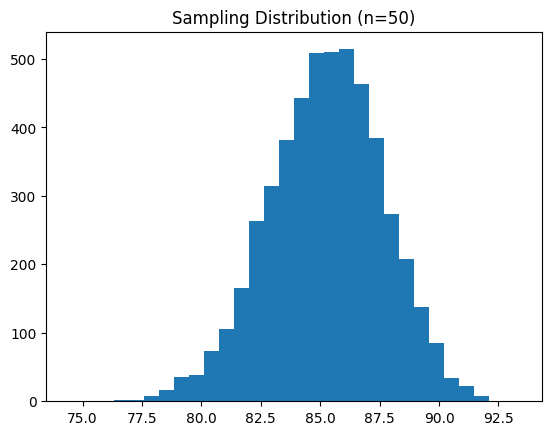

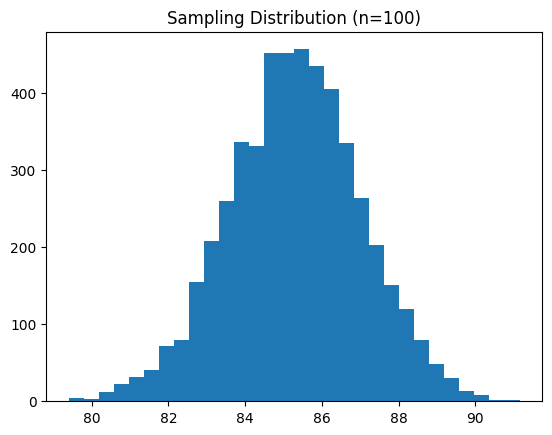

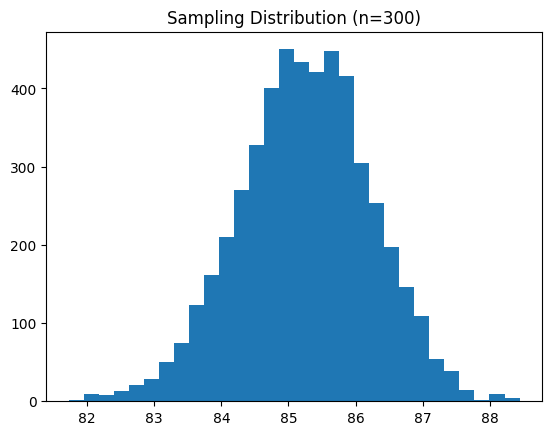

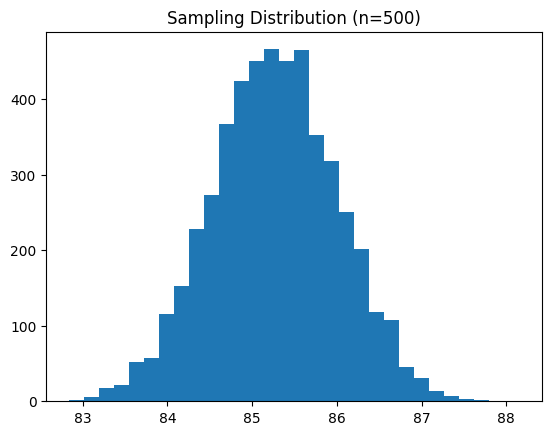

In [ ]:
sample_sizes = [50, 100, 300, 500]
counts = []
records = []

for n in sample_sizes:
  means = []
  count = 0

  for i in range(5000):
    sample = df.sample(n=n, replace=False)

    mean = sample["SatisfactionScore"].mean()
    std = sample["SatisfactionScore"].std()

    se = std / np.sqrt(len(sample))

    margin_error = 1.96 * se

    lower = mean - margin_error
    upper = mean + margin_error

    records.append({
            "sample_size": n,
            "sample_mean": mean,
            "ci_lower": lower,
            "ci_upper": upper
    })

    if lower <= population_mean <= upper:
      count += 1

    means.append(mean)

  counts.append(count/5000)
  plt.hist(means, bins=30)
  plt.title(f"Sampling Distribution (n={n})")
  plt.show()

results = pd.DataFrame(records)
results.to_csv("sampling_results_tableau.csv", index=False)

In [ ]:
counts

[0.9436, 0.9458, 0.9484, 0.9532]